# Importing required Libraries

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Loading the Model

In [34]:
data= pd.read_csv("spotify-2023.csv",encoding='latin-1')
data.head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,144,A,Minor,65,23,80,14,63,11,6


# Label Encoding

In [35]:
encoder = LabelEncoder()
# data['artist(s)_name'] = encoder.fit_transform(data['artist(s)_name'])
# data['track_name'] = encoder.fit_transform(data['track_name'])
# data['mode'] = encoder.fit_transform(data['mode'])
# data['key'] = encoder.fit_transform(data['key'])
# data['streams'] = encoder.fit_transform(data['streams'])
for i in data.columns:
    data[i] = encoder.fit_transform(data[i])
data    



,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,687,326,1,49,6,13,116,81,156,43,...,56,2,0,55,85,65,31,0,5,2
1,397,401,0,49,2,22,315,48,125,48,...,23,3,0,46,57,56,7,0,7,2
2,936,431,0,49,5,29,305,78,151,92,...,69,7,0,26,28,35,17,0,28,4
3,170,558,0,45,7,22,703,74,864,110,...,99,0,0,30,54,54,11,0,8,13
4,864,43,0,49,4,17,514,50,499,82,...,75,0,1,40,19,62,14,34,8,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
948,523,517,0,48,10,2,223,0,912,61,...,75,0,0,35,20,21,57,0,5,1
949,95,558,0,48,9,20,269,0,81,4,...,96,8,0,17,3,6,83,1,9,4
950,14,184,1,48,10,2,121,0,835,2,...,23,3,0,55,77,49,4,0,5,4
951,237,185,2,48,9,19,297,0,127,29,...,28,3,0,57,63,59,8,0,9,3


# Dropping the COlumns

In [36]:
X =data.drop(columns=['streams','in_spotify_playlists' , 'in_spotify_charts','in_apple_playlists', 'bpm', 'danceability_%', 'valence_%', 'energy_%' , 'acousticness_%' , 'instrumentalness_%' , 'liveness_%' , 'speechiness_%' ])
Y= data['streams']

# Splitting

In [37]:
x_train, x_test, y_train, y_test = train_test_split(X,Y,test_size=0.2)

# Loading the Model

In [38]:
model = LinearRegression()
model.fit(x_train , y_train)

LinearRegression()

# Prediction

In [39]:
y_pred = model.predict(x_test)
MSE = root_mean_squared_error(y_test , y_pred)
print(f" Predictions are :: {y_pred}")
print(f" Error is :: {MSE}")

 Predictions are :: [425.69137204 513.0539791  429.33089799 449.52782389 484.44255664
 456.12509253 511.19726559 431.19706864 477.4375131  460.15277779
 459.17874825 475.66439285 468.81732015 438.79004664 472.824243
 443.68820663 468.1580897  496.56536331 516.20753871 456.85208351
 511.24708796 492.18071029 493.25113817 451.20085042 494.80973515
 449.32872521 494.64705969 432.24760919 469.13482335 459.56207145
 435.78929608 493.6279304  480.81230395 493.63865054 468.02047087
 463.20927561 429.02166602 482.60642474 470.30124424 492.55942636
 501.69873485 489.70609847 542.52213445 453.73053333 462.07244738
 447.73480282 425.702929   452.03741075 470.25123068 456.34862962
 463.57131635 513.90920454 515.14017304 415.43897725 458.13487969
 516.06539643 451.95948263 471.74824916 488.53400952 513.59627042
 466.02950966 421.23263358 438.99988549 336.68178567 504.62735391
 428.26395162 413.17309915 443.26373581 487.9477301  433.7164706
 510.81715556 518.71665769 502.03866407 468.85109115 506.97

# Plotting 

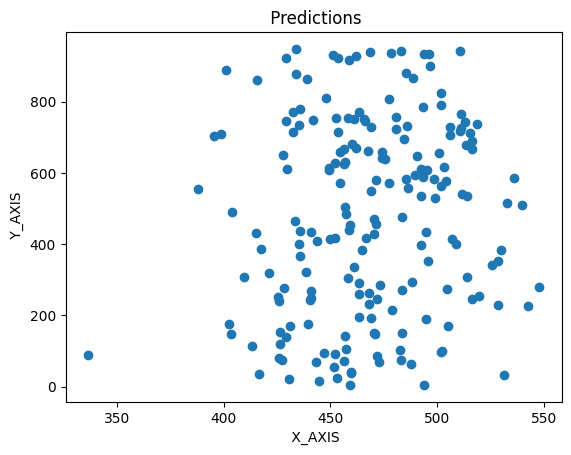

In [40]:
plt.scatter(y_pred , y_test)
plt.xlabel(" X_AXIS")
plt.ylabel(" Y_AXIS")
plt.title(" Predictions")
plt.show()